In [1]:
from sklearn.datasets import load_diabetes
import numpy as np
from itertools import product
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import math

In [2]:
%config InlineBackend.figure_format = 'svg'

## Understanding k-Nearest Neighbours
The **k-Nearest Neighbors (kNN)** algorithm is a simple, non-parametric method used for both classification and regression tasks. It relies on the idea that similar data points tend to be close to each other in feature space. Here’s a breakdown of the mathematics behind kNN:

### 1. Distance Metric

To find the "nearest neighbors" of a data point, $x$, we need a way to measure the distance between $x$ and all other points in the dataset. The most common distance metric used in kNN is the **Euclidean distance**, defined as:

$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

where:
- $x$ and $y$ are two points in $n$-dimensional space.
- $x_i$ and $y_i$ represent the $i$-th feature of $x$ and $y$, respectively.

Other distance metrics like Manhattan distance and Minkowski distance can also be used.

### 2. Finding Nearest Neighbors

Once we choose a distance metric, we calculate the distance between the query point (new data point) and each point in the training set. We then select the $k$ points with the smallest distances to the query point. These are the "k-nearest neighbors."

### 3. Voting for Classification

For a classification problem, kNN uses a majority vote among the $k$-nearest neighbors to classify the query point:
- Each of the $k$ neighbors "votes" for its class.
- The query point is assigned the class that has the majority of votes.

Mathematically, let $c$ be a class and $k_{i,c}$ be the indicator function that equals 1 if neighbor $i$ is of class $c$, and 0 otherwise. Then, the predicted class for the query point $x$ is:

$$
\text{Class}(x) = \arg \max_c \sum_{i=1}^{k} k_{i, c}
$$

where:
- $\arg \max_c$ finds the class $c$ with the highest vote count.

### 4. Averaging for Regression

For regression problems, kNN computes the average of the values of the $k$-nearest neighbors instead of using a majority vote. The prediction for the query point $x$ is:

$$
\hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i
$$

where $y_i$ is the target value of the $i$-th nearest neighbor.

### 5. Choice of $k$

The choice of $k$ is crucial for the performance of the kNN algorithm:
- If $k$ is too small, the algorithm may be sensitive to noise (overfitting).
- If $k$ is too large, the algorithm may capture too much general information and overlook local patterns (underfitting).

Common approaches to choosing $k$ include cross-validation or domain knowledge about the data.

## Getting toy data

In [3]:
d = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [4]:
d.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [5]:
d.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [6]:
categrical_features=['anaemia','diabetes','high_blood_pressure','sex']

In [7]:
features=['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
        'serum_sodium', 'sex', 'smoking', 'time']

In [8]:
data=np.array(d[features])
target_1=np.array(d['DEATH_EVENT'])
target_2=np.array(d['serum_creatinine'])

In [9]:
data=(data-np.mean(data,axis=0))/np.std(data,axis=0)

In [10]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(data, target_1, test_size=0.33, random_state=42)

In [11]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(data, target_2, test_size=0.33, random_state=42)

## Coding the kNN classifier

In [12]:
# Function to calculate Euclidean distance between two points
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

# kNN algorithm for classification
def knn_classification(X_train, y_train, X_test, k=5):
    y_pred = []

    for x_test in X_test:
        # Calculate distances between x_test and all training points
        distances = np.array([euclidean_distance(x_test, x_train) for x_train in X_train])

        # Find the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:k]

        # Find the labels of the k nearest neighbors
        k_nearest_labels = y_train[k_indices]

        # Majority vote
        unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
        majority_vote = unique_labels[np.argmax(counts)]

        y_pred.append(majority_vote)

    return np.array(y_pred)

# kNN algorithm for regression
def knn_regression(X_train, y_train, X_test, k=5):
    y_pred = []

    for x_test in X_test:
        # Calculate distances between x_test and all training points
        distances = np.array([euclidean_distance(x_test, x_train) for x_train in X_train])

        # Find the indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:k]

        # Find the target values of the k nearest neighbors and take the mean
        k_nearest_values = y_train[k_indices]
        mean_value = np.mean(k_nearest_values)

        y_pred.append(mean_value)

    return np.array(y_pred)

## Vizualizing decision boundaries
- We first want to train and test on the training data
- The purpose is to vizualize the decision boundaries (in 2D using PCA) based on different values of $k$

Text(0.5, 1.0, 'PCA plot of Heart failure dataset ')

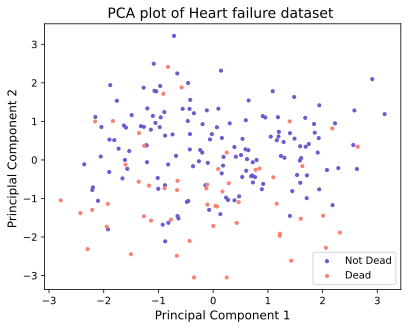

In [13]:
np.random.seed(45)
pca = PCA(n_components =2)
data_pca=pca.fit_transform(X_train_clf)
legend_list=["Not Dead","Dead"]
color_list=np.random.choice(np.array(list(mcolors.CSS4_COLORS.keys())),data.shape[1])

for i in range(len(np.unique(y_train_clf))):
    plt.scatter(data_pca[:,0][np.where(y_train_clf==i)],data_pca[:,1][np.where(y_train_clf==i)], s=10, c=color_list[i])
plt.legend(legend_list, fontsize=10, loc='lower right')
plt.xlabel("Principal Component 1",fontsize=12)
plt.ylabel("Principlal Component 2 ",fontsize=12)
plt.title("PCA plot of Heart failure dataset ",fontsize=14)
#plt.savefig("iris_pca.png", dpi=600)

In [14]:
# Define the mesh grid to plot the decision boundary
x_min, x_max = X_train_clf[:, 0].min() - 1.5, X_train_clf[:, 0].max() + 1.5
y_min, y_max = X_train_clf[:, 1].min() - 2.5, X_train_clf[:, 1].max() + 2.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
X_test_grid = np.c_[xx.ravel(), yy.ravel()]

In [15]:
# Predict classification for each point in the mesh grid
def visualize_decision_boundaries_in_low_d_for_given_k(k):
    Z = knn_classification(data_pca, y_train_clf, X_test_grid, k)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)  # Decision boundary
    for i in range(len(np.unique(y_train_clf))):
        plt.scatter(data_pca[:,0][np.where(y_train_clf==i)],data_pca[:,1][np.where(y_train_clf==i)], s=10, c=color_list[i])
    plt.title(f"k-NN Decision Boundary (k = {k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")

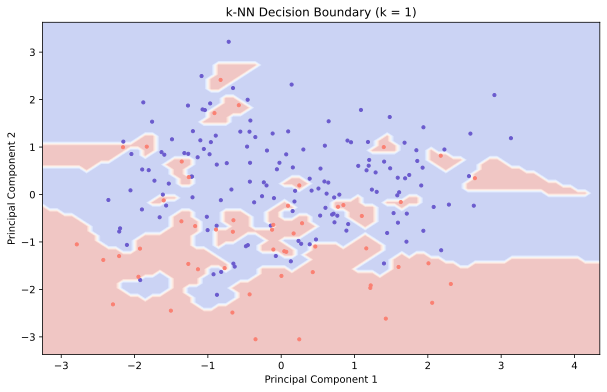

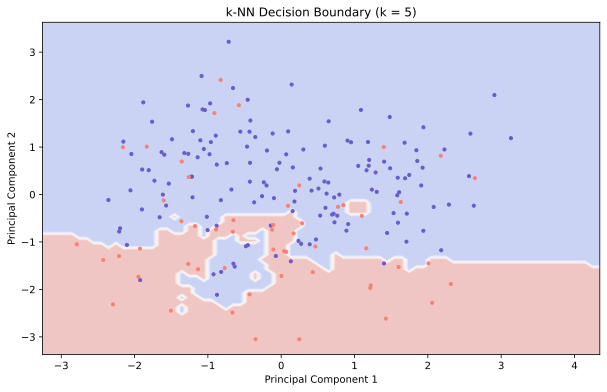

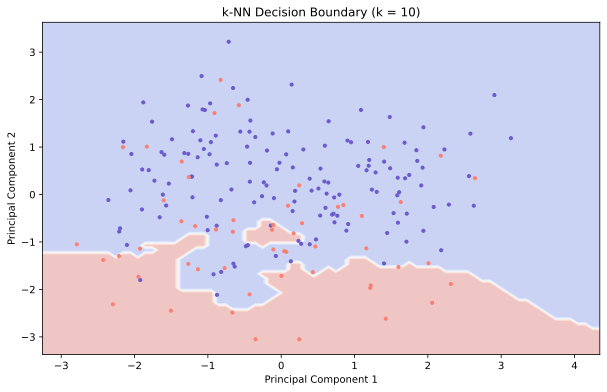

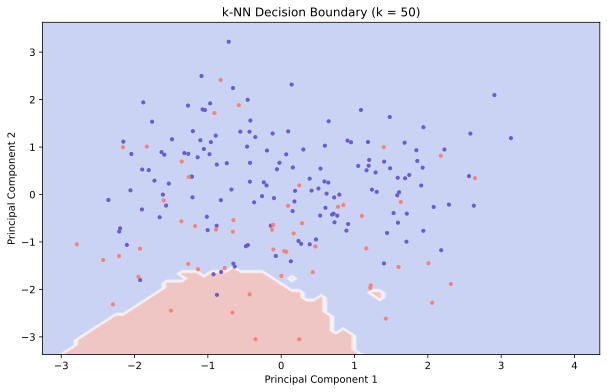

In [16]:
k_list=[1,5,10,50]
for k in k_list:
    visualize_decision_boundaries_in_low_d_for_given_k(k)

## Performace on actual test data

In [17]:
k_list=[1,5,10,15,20,30,40,50,60]
for k in k_list:
    y_pred=knn_classification(X_train_clf, y_train_clf, X_test_clf, k)
    print(f"Confusion matrix for k = {k})")
    print(confusion_matrix(y_test_clf, y_pred))

    print(f"accuracy for k = {k})")
    print(accuracy_score(y_test_clf, y_pred))
    print("\n")

Confusion matrix for k = 1)
[[48  9]
 [31 11]]
accuracy for k = 1)
0.5959595959595959


Confusion matrix for k = 5)
[[55  2]
 [31 11]]
accuracy for k = 5)
0.6666666666666666


Confusion matrix for k = 10)
[[57  0]
 [35  7]]
accuracy for k = 10)
0.6464646464646465


Confusion matrix for k = 15)
[[57  0]
 [36  6]]
accuracy for k = 15)
0.6363636363636364


Confusion matrix for k = 20)
[[57  0]
 [37  5]]
accuracy for k = 20)
0.6262626262626263


Confusion matrix for k = 30)
[[57  0]
 [40  2]]
accuracy for k = 30)
0.5959595959595959


Confusion matrix for k = 40)
[[57  0]
 [41  1]]
accuracy for k = 40)
0.5858585858585859


Confusion matrix for k = 50)
[[57  0]
 [42  0]]
accuracy for k = 50)
0.5757575757575758


Confusion matrix for k = 60)
[[57  0]
 [42  0]]
accuracy for k = 60)
0.5757575757575758




## How to efficiently search for nearest neighbours?

### KD-Tree Construction

Let:
- $D = \{d_1, d_2, \dots, d_n\}$ be a set of $n$ data points in $\mathbb{R}^k$ (a $k$-dimensional space).
- $\text{depth}$ be the current level in the tree.

The construction of a KD-tree is a recursive process, defined as follows:

1. **Splitting Dimension**: At each depth, we select the splitting dimension based on:
   $$
   j = (\text{depth} \mod k)
   $$
   where $j$ is the dimension along which the data will be split. This ensures that dimensions are cycled through from $0$ to $k-1$.

2. **Median Selection**: We compute the median of the data points along the $j$-th dimension:
   $$
   p_j = \text{median}(\{ d_{ij} \mid d_i \in D \})
   $$
   where $d_{ij}$ is the $j$-th coordinate of data point $d_i$. The point $d_{m} \in D$ at the median index becomes the splitting point at this node (we can think that the node contains the data point $d_{m}$), partitioning the data.

3. **Partitioning**: Define two subsets:
   - **Left Subset** $D_L$: All points with $d_{ij} < p_j$.
   - **Right Subset** $D_R$: All points with $d_{ij} \geq p_j$.
   
4. **Recursive Definition**:
   - If $D$ contains only one point, it becomes a leaf node.
   - Otherwise, create a node containing $d_{m}$ and recursively apply the above steps on $D_L$ and $D_R$.


---

### Comment on compexity

#### 1. Number of Nodes and Recursion Depth

- The tree is a binary tree, so it has a height of $O(\log n)$, where $n$ is the number of data points. This is because at each level of the recursion, the dataset is halved.
- In total, the tree will have $n$ nodes (since each point is stored in exactly one node of the tree).

#### 2. Operations at Each Level

At each level of the tree:
- **Finding the Median**: To select the median along the current splitting dimension, we need to sort the points along that dimension.
    - Sorting $n$ points along one dimension has a time complexity of $O(n \log n)$.
- **Splitting the Data**: After sorting, selecting the median is an $O(1)$ operation, but partitioning the data into two subsets based on the median takes linear time, $O(n)$.

#### 3. Recursive Complexity Analysis

- At the root level, we sort $n$ points along one dimension, which takes $O(n \log n)$ time.
- At the next level, we sort $n/2$ points along one of the remaining dimensions, which takes $O(n/2 \log (n/2)) = O(n \log n)$ time (since constants are ignored).
- This process continues recursively, and at each level of recursion, the sorting step takes $O(n \log n)$.

Thus, the most expensive step in creating a KD-tree requires $O(n \log n)$.


---

### Nearest Neighbor Search in KD-Tree

Given a query point $q \in \mathbb{R}^k$, we want to find the point $d^* \in D$ such that the Euclidean distance $\| q - d^* \|$ is minimized.

Let:
- $d_{\text{best}}$ be the closest point to $q$ found so far.
- $d_{\text{min}} = \| q - d_{\text{best}} \|$ be the minimum distance found so far.

The search process is as follows:

1. **Recursive Traversal**:
   - Starting from the root node, we recursively descend the tree based on the value of $q_j$, where $j = (\text{depth} \mod k)$ is the current splitting dimension.
   - If $q_j < d_{j}$, we move to the left subtree; otherwise, we move to the right subtree.

2. **Update Closest Point**:
   - At each node, calculate the Euclidean distance:
     $$
     \| q - d \| = \sqrt{\sum_{i=1}^{k} (q_i - d_i)^2}
     $$
   - If $ \| q - d \| < d_{\text{min}} $, update $d_{\text{best}} = d$ and $d_{\text{min}} = \| q - d \|$.

3. **Bounding Box Check (Backtracking)**:
   - After reaching a leaf node, backtrack and check whether the opposite subtree might contain points closer than $d_{\text{min}}$.
   - The decision is based on the **distance to the splitting plane**:
     $$
     \delta_j = | q_j - d_{j} |
     $$
   - If $ \delta_j < d_{\text{min}} $, we must explore the opposite subtree since there could be points closer to $q$.

4. **Termination**: The search terminates once all possible branches where a closer point could exist have been explored.

This process allows the nearest neighbor to be found in $O(\log n)$ on average in lower dimensions, but performance may approach $O(n)$ in high-dimensional spaces due to the curse of dimensionality.


### Dataset
We are given the following 3D points:  

$$
P = \{(2, 3, 7), (5, 4, 2), (9, 6, 1), (4, 7, 5), (8, 1, 9), (7, 2, 6)\}
$$

We want to build a KD-tree and find the nearest neighbor for the query point:  

$$
Q = (9, 2, 4)
$$

---

### Step 1: Building the KD-Tree  

The KD-tree is constructed recursively by alternating the splitting dimension ($x$, $y$, $z$).

#### Tree Construction
1. **Root Node (split on $x$):**
   - Sort the points by $x$:  
     $$
     [(2, 3, 7), (4, 7, 5), (5, 4, 2), (7, 2, 6), (8, 1, 9), (9, 6, 1)]
     $$
   - Median index:  
     $$
     \frac{n-1}{2} = \frac{6-1}{2} = 2.5 \implies \text{Median = } (7, 2, 6)
     $$
   - Split: $x = 7$.

   Left subtree:  
   $$
   \{(2, 3, 7), (4, 7, 5), (5, 4, 2)\}
   $$  
   Right subtree:  
   $$
   \{(8, 1, 9), (9, 6, 1)\}
   $$

2. **Left Subtree (split on $y$):**
   - Sort the points by $y$:  
     $$
     [(2, 3, 7), (5, 4, 2), (4, 7, 5)]
     $$
   - Median index:  
     $$
     \frac{n-1}{2} = \frac{3-1}{2} = 1 \implies \text{Median = } (5, 4, 2)
     $$
   - Split: $y = 4$.

   Left child:  
   $$
   (2, 3, 7)
   $$  
   Right child:  
   $$
   (4, 7, 5)
   $$

3. **Right Subtree (split on $y$):**
   - Sort the points by $y$:  
     $$
     [(8, 1, 9), (9, 6, 1)]
     $$
   - Median index:  
     $$
     \frac{n-1}{2} = \frac{2-1}{2} = 0.5 \implies \text{Median = } (9, 6, 1)
     $$
   - Split: $y = 6$.

   Left child:  
   $$
   (8, 1, 9)
   $$  
   Right child: None.

---

### Step 2: Nearest Neighbor Search

#### Query Point
$$
Q = (9, 2, 4)
$$

#### Search Process
1. **Start at the Root Node ($(7, 2, 6)$):**
   - Distance:  
     $$
     \sqrt{(9 - 7)^2 + (2 - 2)^2 + (4 - 6)^2} = \sqrt{4 + 0 + 4} = 2.83
     $$  
   - Go to the right subtree since $9 > 7$.

2. **Right Subtree Root ($(9, 6, 1)$):**
   - Distance:  
     $$
     \sqrt{(9 - 9)^2 + (2 - 6)^2 + (4 - 1)^2} = \sqrt{0 + 16 + 9} = \sqrt{25} = 5
     $$  
   - Current nearest: $(7, 2, 6)$ with distance $2.83$.  
   - Go to the left child since $2 < 6$.

3. **Left Child ($(8, 1, 9)$):**
   - Distance:  
     $$
     \sqrt{(9 - 8)^2 + (2 - 1)^2 + (4 - 9)^2} = \sqrt{1 + 1 + 25} = \sqrt{27} \approx 5.2
     $$  
   - Current nearest remains $(7, 2, 6)$.

4. **Backtracking:**
   - Check if the splitting hyperplanes might contain closer points:
     - For the root $x = 7$, the distance to the for the first dimension is $|9 - 7| = 2$, less than the nearest distance $2.83$.  
       - Check the left subtree of the root.

5. **Left Subtree Root ($(5, 4, 2)$):**
   - Distance:  
     $$
     \sqrt{(9 - 5)^2 + (2 - 4)^2 + (4 - 2)^2} = \sqrt{16 + 4 + 4} = \sqrt{24} \approx 4.9
     $$  
   - Current nearest remains $(7, 2, 6)$.

6. **Left Child of Left Subtree ($(2, 3, 7)$):**
   - Distance:  
     $$
     \sqrt{(9 - 2)^2 + (2 - 3)^2 + (4 - 7)^2} = \sqrt{49 + 1 + 9} = \sqrt{59} \approx 7.68
     $$  
   - No closer points found.

7. **Right Child of Left Subtree ($(4, 7, 5)$):**
   - Distance:  
     $$
     \sqrt{(9 - 4)^2 + (2 - 7)^2 + (4 - 5)^2} = \sqrt{25 + 25 + 1} = \sqrt{51} \approx 7.14
     $$  
   - No closer points found.

---

### Final Result
The nearest neighbor to $Q = (9, 2, 4)$ is:  

$$
(7, 2, 6)
$$

with a distance of $2.83$.


In [18]:
def build_kd_tree(points, depth=0):
    """
    Builds a KD-Tree recursively from a NumPy array of points.
    """
    if len(points) == 0:
        return None

    # Determine the splitting axis (x=0, y=1, z=2)
    axis = depth % points.shape[1]

    # Sort points along the splitting axis
    points = points[points[:, axis].argsort()]

    # Find the median index
    median = len(points) // 2

    # Recursively construct the tree
    return {
        'point': points[median],
        'left': build_kd_tree(points[:median], depth + 1),
        'right': build_kd_tree(points[median + 1:], depth + 1)
    }

def distance(point1, point2):
    """
    Calculates Euclidean distance between two points.
    """
    return np.sqrt(np.sum((point1 - point2) ** 2))

def nearest_neighbor(node, query_point, depth=0, best=None):
    """
    Finds the nearest neighbor in the KD-Tree.
    """
    if node is None:
        return best

    # Current point and axis
    current_point = node['point']
    axis = depth % current_point.shape[0]

    # Update the best point if the current point is closer
    if best is None or distance(query_point, current_point) < distance(query_point, best):
        best = current_point

    # Choose the subtree to search based on the splitting axis
    if query_point[axis] < current_point[axis]:
        next_branch = node['left']
        other_branch = node['right']
    else:
        next_branch = node['right']
        other_branch = node['left']

    # Search the chosen subtree
    best = nearest_neighbor(next_branch, query_point, depth + 1, best)

    # Check the other subtree if necessary
    if abs(query_point[axis] - current_point[axis]) < distance(query_point, best):
        best = nearest_neighbor(other_branch, query_point, depth + 1, best)

    return best


In [19]:
tree=build_kd_tree(data)

In [20]:
nearest_neighbor(tree, (data[0]+data[100])/2, depth=0, best=None)

array([-0.07022315,  1.14796753, -0.44167996, -0.84757938, -1.10736987,
       -0.73568819, -0.54647409, -0.36898615,  0.73568819, -0.68768191,
       -0.622847  ])